<a href="https://colab.research.google.com/github/rfaoktvian/AI-Resume-Screener/blob/main/AI_Resume_Screener_Tugas_Besar_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tugas Besar Kecerdasan Buatan (Artificial Intelligence)
## Proyek: AI Resume Screener

---

### 📝 Deskripsi Proyek
Proyek ini bertujuan untuk membangun sebuah sistem penyaring resume otomatis (**AI Resume Screener**) berbasis Machine Learning / NLP. Sistem ini dirancang untuk membantu tim HRD dalam menyaring, mengklasifikasikan, dan menganalisis dokumen resume/CV pelamar kerja secara efisien berdasarkan kategori pekerjaan yang sesuai.

### 👤 Anggota Tim / Identitas
* **Nama Anggota Kelompok:**
  1. Nazly Rafa Oktafian Nuzqu (2311103078)
  2. Setyo Prabowo Anom Senjoyo (2311103067)
  3. Akmal Rafly Dzunurain (2311103076)
* **Kelas:** REG-02
* **Dosen Pengampu:** Sena W

### 🚀 Alur Kerja (Workflow)
1. **Data Loading & Exploration:** Memuat dataset resume dan melakukan analisis awal.
2. **Text Preprocessing:** Membersihkan teks resume (cleansing, tokenization, stopword removal, stemming/lemmatization).
3. **Feature Extraction:** Mengubah teks menjadi representasi numerik (TF-IDF / Word Embedding).
4. **Model Training:** Melatih model klasifikasi (misal: SVM, Random Forest, atau Naive Bayes).
5. **Evaluation:** Menguji performa model menggunakan akurasi, precision, recall, dan F1-score.

---

### INSTALL LIBRARY

In [182]:
!pip install -q sentence-transformers xgboost scikit-learn pandas numpy \
             matplotlib seaborn scipy

### IMPORT LIBRARY

In [183]:
import pandas as pd
import numpy as np
import re, os, json, pickle, warnings
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix,
    precision_recall_curve
)
from xgboost import XGBClassifier
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')

WORK_DIR    = '/content/drive/MyDrive/Kuliah/SEMESTER 6/AI/Tugas Besar'
DATASET_PATH = f'{WORK_DIR}/resume_dataset_fixed.csv'
OUTPUT_DIR   = f'{WORK_DIR}/models'

os.makedirs(WORK_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f'Work dir: {WORK_DIR}')
print(f'Dataset : {DATASET_PATH}')
print(f'Output dir  : {OUTPUT_DIR}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Work dir: /content/drive/MyDrive/Kuliah/SEMESTER 6/AI/Tugas Besar
Dataset : /content/drive/MyDrive/Kuliah/SEMESTER 6/AI/Tugas Besar/resume_dataset_fixed.csv
Output dir  : /content/drive/MyDrive/Kuliah/SEMESTER 6/AI/Tugas Besar/models


### LOAD DATASET

In [184]:
df = pd.read_csv(DATASET_PATH, sep=';', engine='python',
                 on_bad_lines='skip', quotechar='"')

### DATA UNDERSTANDING

In [185]:
df.head()

,Role,Resume,Job_Description,Decision,Decision_binary,Reason_for_decision
0,HR Specialist,Here's a professional resume for Patrick Mccla...,"Manage the full-cycle recruitment process, spe...",reject,0,Below-median technical profile for HR Speciali...
1,HR Specialist,Here's a professional resume for Charles Gonza...,"Manage the full-cycle recruitment process, spe...",select,1,Sufficient experience (6 entries) and Bachelor...
2,Data Engineer,Here's a professional resume for Mrs. Brittany...,"Design, develop, and maintain robust, scalable...",select,1,Strong technical fit: 14/28 required skills (5...
3,Data Analyst,"Here's a sample resume for Carol Smith, applyi...","Design, develop, and maintain interactive busi...",select,1,Sufficient experience (6 entries) and Bachelor...
4,HR Specialist,Here's a sample resume for Janet Ortiz:\n\nJan...,"Manage the full-cycle recruitment process, spe...",select,1,Sufficient experience (6 entries) and Bachelor...


In [186]:
df.columns

Index(['Role', 'Resume', 'Job_Description', 'Decision', 'Decision_binary',
       'Reason_for_decision'],
      dtype='object')

In [187]:
df.describe()

,Decision_binary
count,3152.000000
mean,0.507931
std,0.500016
min,0.000000
25%,0.000000
50%,1.000000
75%,1.000000
max,1.000000


In [188]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3152 entries, 0 to 3151
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Role                 3152 non-null   object
 1   Resume               3152 non-null   object
 2   Job_Description      3152 non-null   object
 3   Decision             3152 non-null   object
 4   Decision_binary      3152 non-null   int64 
 5   Reason_for_decision  3152 non-null   object
dtypes: int64(1), object(5)
memory usage: 147.9+ KB


In [189]:
df.isnull().sum()

,0
Role,0
Resume,0
Job_Description,0
Decision,0
Decision_binary,0
Reason_for_decision,0


In [190]:
df.duplicated().sum()

np.int64(0)

In [191]:
df['Role'].unique()

array(['HR Specialist', 'Data Engineer', 'Data Analyst', 'Data Scientist',
       'Software Engineer'], dtype=object)

In [192]:
vc = df['Decision_binary'].value_counts()
print(f'  select (1) : {vc.get(1,0)} ({vc.get(1,0)/len(df)*100:.1f}%)')
print(f'  reject (0) : {vc.get(0,0)} ({vc.get(0,0)/len(df)*100:.1f}%)')

  select (1) : 1601 (50.8%)
  reject (0) : 1551 (49.2%)


### EXPLORATORT DATA ANALYSIS

In [193]:
# Resume Length
df['resume_len'] = df['Resume'].str.len()
print(df.groupby('Role')['resume_len'].agg(['min','mean','max']).round(0).to_string())

                    min    mean   max
Role                                 
Data Analyst       1713  2934.0  4652
Data Engineer      1743  2919.0  4178
Data Scientist     1418  2975.0  4497
HR Specialist      1827  2975.0  3980
Software Engineer   597  2796.0  4383


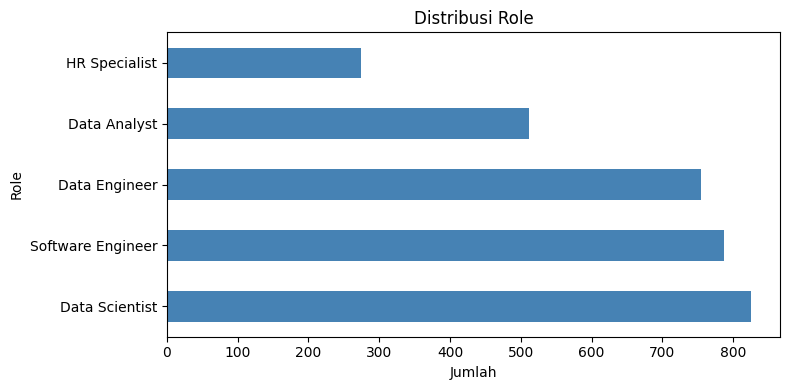

In [194]:
# Distribusi Role
fig, ax = plt.subplots(figsize=(8, 4))

df['Role'].value_counts().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Distribusi Role')
ax.set_xlabel('Jumlah')

plt.tight_layout()
plt.show()

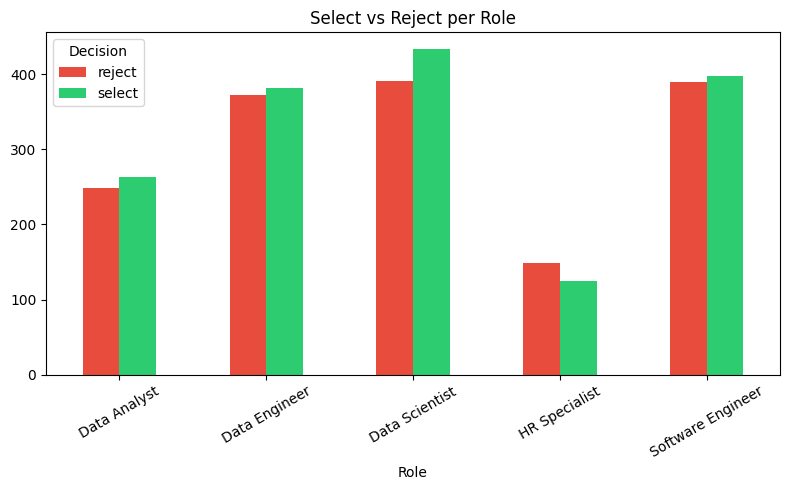

In [195]:
# Label Distribution per Role
fig, ax = plt.subplots(figsize=(8, 5))

df.groupby(['Role', 'Decision'])['Decision'].count().unstack().plot(
    kind='bar',
    ax=ax,
    color=['#e74c3c', '#2ecc71']
)

ax.set_title('Select vs Reject per Role')
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

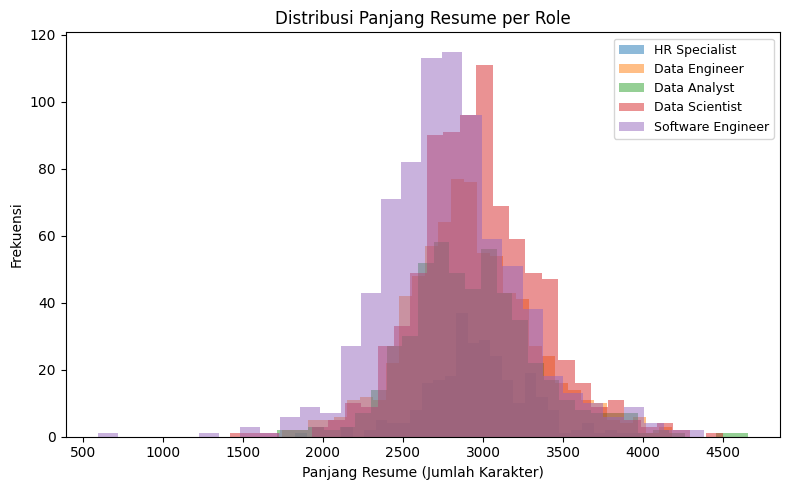

In [196]:
# Resume Length Distribution
fig, ax = plt.subplots(figsize=(8, 5))
for role in df['Role'].unique():
    subset = df[df['Role'] == role]['resume_len']
    ax.hist(subset, bins=30, alpha=0.5, label=role)

ax.set_title('Distribusi Panjang Resume per Role')
ax.set_xlabel('Panjang Resume (Jumlah Karakter)')
ax.set_ylabel('Frekuensi')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

### DATA PREPROCESSING

In [197]:
# clean text
def clean_text(text: str) -> str:
    """Hapus markdown noise, karakter berlebih, normalisasi whitespace."""
    if not isinstance(text, str):
        return ''
    text = re.sub(r'\[([^\]]+)\]\([^)]+\)', r'\1', text)
    text = re.sub(r'[*#~>`]', ' ', text)
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)
    text = re.sub(r'[^\w\s.,\-+/@()]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [198]:
df['Resume_clean'] = df['Resume'].apply(clean_text)
df['JD_clean']     = df['Job_Description'].apply(clean_text)

In [199]:
df['Role'] = df['Role'].str.strip().str.title()

In [200]:
df['Resume'].head()

,Resume
0,Here's a professional resume for Patrick Mccla...
1,Here's a professional resume for Charles Gonza...
2,Here's a professional resume for Mrs. Brittany...
3,"Here's a sample resume for Carol Smith, applyi..."
4,Here's a sample resume for Janet Ortiz:\n\nJan...


In [201]:
df['Resume_clean'].head()

,Resume_clean
0,Here s a professional resume for Patrick Mccla...
1,Here s a professional resume for Charles Gonza...
2,Here s a professional resume for Mrs. Brittany...
3,"Here s a sample resume for Carol Smith, applyi..."
4,Here s a sample resume for Janet Ortiz Janet O...


In [202]:
df['Role'].unique()

array(['Hr Specialist', 'Data Engineer', 'Data Analyst', 'Data Scientist',
       'Software Engineer'], dtype=object)

In [203]:
# Filter resume terlalu pendek
before_filter = len(df)

df = df[df['Resume_clean'].str.len() >= 500].reset_index(drop=True)

after_filter = len(df)
removed_rows = before_filter - after_filter

print(f"Jumlah baris yang dihapus: {removed_rows} baris.")
print(f"Total data sekarang      : {after_filter} baris.")

Jumlah baris yang dihapus: 0 baris.
Total data sekarang      : 3152 baris.


In [204]:
df.shape

(3152, 9)

### SETUP JOB DESCRIPTION

In [205]:
JD_REAL = {

    "Data Analyst": """
    Design, develop, and maintain interactive business intelligence dashboards to monitor
    daily operational metrics and strategic initiatives for Management and Product teams.
    Perform deep-dive exploratory data analysis on retail business metrics, including
    customer retention, sales performance, inventory turnover, and basket analysis.
    Develop and maintain reliable data marts, utilizing dimensional modeling to structure
    retail transaction and inventory tables. Translate complex business questions from
    Marketing and Supply Chain teams into actionable analytical solutions and regular
    ad-hoc reports.
    Qualifications: Bachelor degree in Information Systems, Statistics, Industrial
    Engineering, or Business Management. 2+ years of experience as a Data Analyst or
    Business Intelligence Analyst.
    Technical Skills: Advanced SQL (window functions, complex joins, performance tuning),
    hands-on experience with BI tools (Power BI, Tableau, Looker, or Metabase),
    understanding of data warehouse concepts, Python or R for analysis,
    spreadsheet automation (Google Apps Script or Excel VBA).
    """,

    "Data Engineer": """
    Design, develop, and maintain robust, scalable, and automated data pipelines (ETL/ELT)
    to integrate high-volume retail data from POS systems, ERP, and e-commerce platforms.
    Build and optimize data pipelines and orchestration workflows using Apache Airflow,
    implementing clean DAG designs and rigorous scheduling. Design and maintain cloud-based
    data warehousing architectures and scalable big data infrastructures to handle batch
    and real-time streaming data. Collaborate with Data Science teams to implement MLOps
    foundations, including model deployment pipelines, monitoring systems, and automated
    data versioning. Optimize query performance and storage efficiency across distributed
    computing frameworks and NoSQL databases.
    Qualifications: Bachelor degree in Computer Science, Information Technology, or a
    related technical field. 3+ years of working experience as a Data Engineer.
    Technical Skills: Advanced ETL/ELT pipelines, Apache Airflow (DAG management),
    Big Data technologies (Apache Spark, Hadoop), Cloud Platforms (GCP/BigQuery,
    AWS/Redshift, or Azure/Snowflake), NoSQL and relational databases, core MLOps concepts.
    """,

    "Data Scientist": """
    Design and deploy advanced machine learning models for demand forecasting, inventory
    optimization, and automated dynamic pricing in retail operations. Develop personalized
    recommendation engines and advanced customer segmentation models (RFM analysis, churn
    prediction) for target marketing campaigns. Conduct rigorous A/B testing and statistical
    analysis to evaluate the business impact of new app features, promotional strategies,
    and layout changes. Build end-to-end predictive pipelines and collaborate with Data
    Engineers to seamlessly deploy models into production environments.
    Qualifications: Bachelor or Master degree in Computer Science, Statistics, Mathematics,
    or Data Science. 3+ years of experience developing and deploying ML models in production.
    Technical Skills: Advanced Python and R, Machine Learning Frameworks (Scikit-Learn,
    TensorFlow, Keras), Deep Learning for tabular and image data (CNNs), Statistical
    modeling, A/B Testing framework, cloud ML tools (Vertex AI or AWS SageMaker).
    """,

    "Software Engineer": """
    Design, develop, and maintain high-traffic web and mobile applications for e-commerce
    platforms and internal retail management systems (POS, Inventory tracking). Build
    robust, secure, and scalable RESTful APIs and microservices architectures to seamlessly
    connect frontend applications with backend retail servers. Write clean, well-tested,
    and maintainable code, participating actively in code reviews and CI/CD pipelines.
    Monitor application performance, troubleshoot production issues, and optimize
    application speed and database query execution.
    Qualifications: Bachelor degree in Computer Science, Software Engineering, or
    equivalent experience. 2+ years of experience in full-stack, backend, or frontend
    software development.
    Technical Skills: Proficiency in modern languages (Python, Node.js, Go, or Java),
    framework experience (Django, Express, or Spring Boot), RESTful API design,
    CI/CD pipelines (GitLab, GitHub Actions), Docker containerization, relational
    database management.
    """,

    "Hr Specialist": """
    Manage the full-cycle recruitment process, specifically designing mass recruitment
    strategies for retail store operations, cashiers, and corporate professional roles.
    Screen resumes, conduct structured interviews, and leverage modern ATS (Applicant
    Tracking Systems) to build an efficient talent acquisition pipeline. Design and execute
    comprehensive employee onboarding programs, performance management frameworks
    (KPI alignments), and talent retention initiatives. Handle employee relations,
    compliance with local labor laws, and coordinate internal training programs.
    Qualifications: Bachelor degree in Psychology, Human Resource Management, Law,
    or Business Administration. 2+ years of experience as an HR Specialist or Recruiter,
    preferably handling high-volume hiring.
    Technical Skills: Experience with ATS tools (Talentlink, Darwinbox, Greenhouse),
    HR Information Systems (HRIS), knowledge of Indonesian Labor Law (UU Ketenagakerjaan),
    structured interview techniques (BEI), and HR metrics reporting and analytics.
    """,
}

roles_in_dataset = set(df['Role'].unique())
roles_in_jd      = set(JD_REAL.keys())
missing          = roles_in_dataset - roles_in_jd

print(' Role di dataset     :', sorted(roles_in_dataset))
print(' Role di JD_REAL     :', sorted(roles_in_jd))

if missing:
    print(f'\n Role BELUM ada JD: {missing}')
    print('   Tambahkan JD untuk role tersebut di dict JD_REAL di atas!')
else:
    print('\n Semua role sudah punya JD real')

 Role di dataset     : ['Data Analyst', 'Data Engineer', 'Data Scientist', 'Hr Specialist', 'Software Engineer']
 Role di JD_REAL     : ['Data Analyst', 'Data Engineer', 'Data Scientist', 'Hr Specialist', 'Software Engineer']

 Semua role sudah punya JD real


In [206]:
# Map JD ke setiap baris
df['JD_real'] = df['Role'].map(JD_REAL)
df['JD_real'] = df['JD_real'].apply(lambda x: re.sub(r'\s+', ' ', x).strip() if isinstance(x, str) else '')

print(f'\nContoh JD real (Data Analyst, 300 chars):')
print(df[df['Role']=='Data Analyst']['JD_real'].iloc[0][:300])


Contoh JD real (Data Analyst, 300 chars):
Design, develop, and maintain interactive business intelligence dashboards to monitor daily operational metrics and strategic initiatives for Management and Product teams. Perform deep-dive exploratory data analysis on retail business metrics, including customer retention, sales performance, invento


### SBERT EMBEDDING & SIMILARITY

In [207]:
SBERT_MODEL_NAME = 'sentence-transformers/all-MiniLM-L6-v2'
sbert = SentenceTransformer(SBERT_MODEL_NAME)
print('Model loaded\n')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded



In [208]:
# Encode JD
print('Encoding JD per role...')
unique_roles   = list(JD_REAL.keys())
jd_texts       = [JD_REAL[r] for r in unique_roles]
jd_embeddings  = sbert.encode(jd_texts, show_progress_bar=True,
                               batch_size=8, normalize_embeddings=True)
jd_emb_dict    = dict(zip(unique_roles, jd_embeddings))

Encoding JD per role...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

In [209]:
# Encode semua resume
print(f'\nEncoding {len(df)} resume...')
resume_embeddings = sbert.encode(
    df['Resume_clean'].tolist(),
    show_progress_bar=True,
    batch_size=64,
    normalize_embeddings=True
)
print(f'Resume embeddings shape: {resume_embeddings.shape}')


Encoding 3152 resume...


Batches:   0%|          | 0/50 [00:00<?, ?it/s]

Resume embeddings shape: (3152, 384)


In [210]:
# Hitung cosine similarity
sbert_scores = []
for i, role in enumerate(df['Role']):
    jd_vec = jd_emb_dict.get(role)
    sim    = cosine_similarity(resume_embeddings[i].reshape(1,-1),
                               jd_vec.reshape(1,-1))[0][0] if jd_vec is not None else 0.0
    sbert_scores.append(float(sim))

df['sbert_similarity'] = sbert_scores

print('\nSBERT similarity per label:')
print(df.groupby('Decision')['sbert_similarity'].describe()[['mean','std']].round(3))
print('SBERT selesai')


SBERT similarity per label:
           mean    std
Decision              
reject    0.613  0.097
select    0.665  0.067
SBERT selesai


In [211]:
print('\nSBERT similarity stats per role:')
print(df.groupby('Role')['sbert_similarity'].agg(['min','mean','max']).round(3).to_string())


SBERT similarity stats per role:
                     min   mean    max
Role                                  
Data Analyst       0.491  0.652  0.784
Data Engineer      0.342  0.718  0.843
Data Scientist     0.329  0.632  0.788
Hr Specialist      0.510  0.621  0.732
Software Engineer  0.312  0.570  0.718


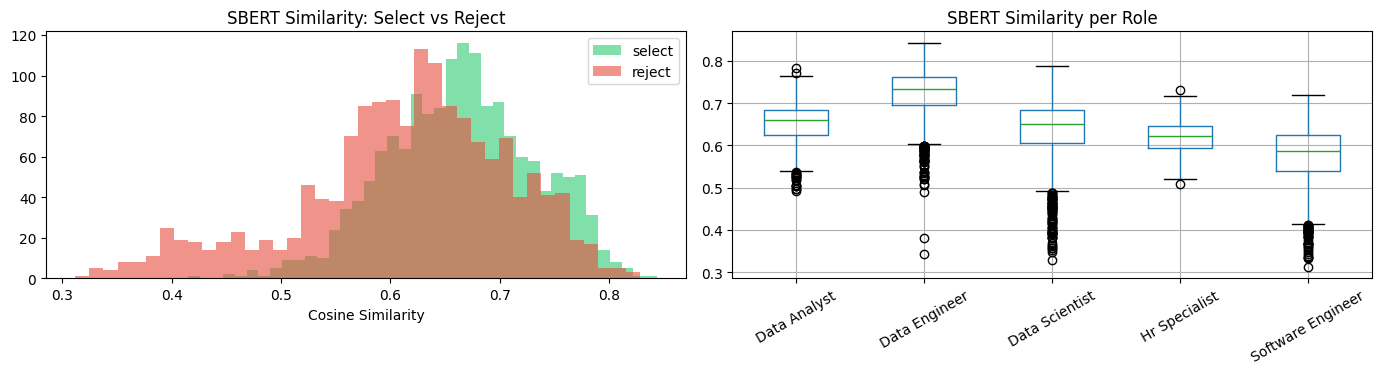

In [212]:
# Visualisasi distribusi similarity
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for dec, color in [('select','#2ecc71'), ('reject','#e74c3c')]:
    subset = df[df['Decision']==dec]['sbert_similarity']
    axes[0].hist(subset, bins=40, alpha=0.6, label=dec, color=color)
axes[0].set_title('SBERT Similarity: Select vs Reject')
axes[0].set_xlabel('Cosine Similarity'); axes[0].legend()

df.boxplot(column='sbert_similarity', by='Role', ax=axes[1])
axes[1].set_title('SBERT Similarity per Role')
axes[1].set_xlabel(''); plt.suptitle('')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

### FEATURE EXTRACTION

In [213]:
SKILLS_PER_ROLE = {
    'Data Analyst': ['sql','python','r','power bi','tableau','looker','metabase','excel',
        'bigquery','redshift','snowflake','data warehouse','dbt','etl','pandas','numpy',
        'statistics','hypothesis testing','regression','a/b testing','dimensional modeling',
        'google sheets','visualization'],
    'Data Engineer': ['python','sql','spark','hadoop','airflow','kafka','flink','dbt',
        'etl','elt','bigquery','redshift','snowflake','aws','gcp','azure','docker',
        'kubernetes','data pipeline','data warehouse','mlops','dag','nosql','mongodb',
        'postgresql','mysql','pyspark','terraform'],
    'Data Scientist': ['python','r','sql','machine learning','deep learning','tensorflow',
        'keras','pytorch','scikit-learn','sklearn','xgboost','lightgbm','nlp',
        'computer vision','statistics','a/b testing','pandas','numpy','feature engineering',
        'mlops','model deployment','sagemaker','mlflow'],
    'Software Engineer': ['python','java','javascript','typescript','go','node.js','react',
        'vue','django','flask','fastapi','spring','rest api','graphql','microservices',
        'docker','kubernetes','ci/cd','git','postgresql','mysql','mongodb','redis',
        'aws','gcp','azure','system design'],
    'Hr Specialist': ['recruitment','talent acquisition','onboarding','hris','ats',
        'performance management','kpi','payroll','employee relations','labor law',
        'training','development','interviewing','compensation',
        'organizational development','darwinbox','greenhouse']
}

In [214]:
def extract_skills_score(text, role):
    t = text.lower()
    sl = SKILLS_PER_ROLE.get(role, [])
    if not sl:
        return 0.0

    jumlah_match = sum(1 for s in sl if s in t)

    target_skill = 8.0
    return min(jumlah_match / target_skill, 1.0)

In [215]:
def extract_years_experience(text):
    patterns = [
        r'\b(19|20)\d{2}\s*[-–]\s*(present|now|current|(19|20)\d{2})\b',
        r'\b(jan|feb|mar|apr|may|jun|jul|aug|sep|oct|nov|dec)[a-z]*\.?\s*(19|20)\d{2}',
        r'\(\s*(19|20)\d{2}\s*[-–]',
    ]
    c = sum(len(re.findall(p, text.lower())) for p in patterns)
    return min(c, 8) / 8.0  # normalized 0-1

In [216]:
def extract_has_portfolio(text):
  return int(any(re.search(p, text.lower()) for p in
              [r'github\.com', r'gitlab\.com', r'behance\.net', r'\bportfolio\b']))

In [217]:
def extract_has_certification(text):
    patterns = [
        r'certif',
        r'certificate',
        r'certification',
        r'sertifikat',
        r'sertifikasi',
        r'bootcamp',
        r'cohort',
        r'\bcourse\b',
        r'\blicense\b'
    ]

    return int(
        any(
            re.search(p, text.lower())
            for p in patterns
        )
    )

In [218]:
def extract_education_level(text):
    t = text.lower()
    if re.search(r'\bphd\b|\bdoctor|\bs3\b', t): return 1.0
    elif re.search(r'\bmaster|\bm\.s|\bmagister|\bs2\b|\bmba\b', t): return 0.67
    elif re.search(r'\bbachelor|\bsarjana|\bs1\b|\bb\.eng|\bundergrad', t): return 0.33
    elif re.search(r'\bdiploma|\bd3\b|\bd4\b|\bassociate', t): return 0.0
    return 0.33

In [219]:
df['skills_score']      = df.apply(lambda r: extract_skills_score(r['Resume_clean'], r['Role']), axis=1)
df['years_exp_norm']    = df['Resume_clean'].apply(extract_years_experience)
df['has_portfolio']     = df['Resume_clean'].apply(extract_has_portfolio)
df['has_certification'] = df['Resume_clean'].apply(extract_has_certification)
df['education_level']   = df['Resume_clean'].apply(extract_education_level)

FEATURE_COLS = ['sbert_similarity','skills_score','years_exp_norm',
                'has_portfolio','has_certification','education_level']

print('Korelasi fitur vs label:')
for col in FEATURE_COLS:
    corr, _ = stats.pointbiserialr(df['Decision_binary'], df[col])
    bar = '█' * int(abs(corr)*30)
    print(f'  {col:<22}: {corr:+.4f}  {bar}')
print('\nFeature extraction selesai')

Korelasi fitur vs label:
  sbert_similarity      : +0.2950  ████████
  skills_score          : +0.3276  █████████
  years_exp_norm        : +0.6438  ███████████████████
  has_portfolio         : +0.3124  █████████
  has_certification     : +0.4414  █████████████
  education_level       : +0.3850  ███████████

Feature extraction selesai


### FEATURE ENGINEERING

In [220]:
X = df[FEATURE_COLS].values.astype(np.float32)
y = df['Decision_binary'].values


In [221]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.15, random_state=42, stratify=y_train_full
)


In [222]:
INPUT_EXAMPLE = pd.DataFrame(
    [X_test[0]], columns=FEATURE_COLS
)

print(f'Train : {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}')
print(f'Features: {FEATURE_COLS}')
print(f'\nInput example (untuk MLflow serving):')
print(INPUT_EXAMPLE.to_string())

Train : 2142 | Val: 379 | Test: 631
Features: ['sbert_similarity', 'skills_score', 'years_exp_norm', 'has_portfolio', 'has_certification', 'education_level']

Input example (untuk MLflow serving):
   sbert_similarity  skills_score  years_exp_norm  has_portfolio  has_certification  education_level
0          0.660431           1.0             0.5            1.0                1.0             0.33


### MODELLING

In [223]:
xgb_params = dict(
    n_estimators     = 500,
    max_depth        = 3,
    learning_rate    = 0.03,
    subsample        = 0.7,
    colsample_bytree = 0.7,
    min_child_weight = 10,
    reg_alpha        = 0.5,
    reg_lambda       = 2.0,
    eval_metric      = 'logloss',
    random_state     = 42,
    verbosity        = 0
)

xgb_train = XGBClassifier(**xgb_params, early_stopping_rounds=30)

In [224]:
MODELS = {
    'LogisticRegression': LogisticRegression(
        C=0.5, max_iter=1000, random_state=42),
    'RandomForest': RandomForestClassifier(
        n_estimators=200, max_depth=5,
        min_samples_leaf=10, max_features='sqrt', random_state=42),
    'XGBoost': xgb_train
}

results        = {}
trained_models = {}

In [225]:

for name, model in MODELS.items():
    print(f'\n{"─"*45}')
    print(f'Training: {name}')

    # Fit
    if name == 'XGBoost':
        model.fit(X_train, y_train,
                  eval_set=[(X_val, y_val)], verbose=False)
        best_iter = model.best_iteration
        print(f'  Best iteration : {best_iter}')

        xgb_cv = XGBClassifier(**{**xgb_params, 'n_estimators': best_iter})
        cv_scores = cross_val_score(
            xgb_cv, X_train_full, y_train_full,
            cv=StratifiedKFold(5, shuffle=True, random_state=42),
            scoring='f1', n_jobs=-1
        )
    else:
        model.fit(X_train_full, y_train_full)
        cv_scores = cross_val_score(
            model, X_train_full, y_train_full,
            cv=StratifiedKFold(5, shuffle=True, random_state=42),
            scoring='f1', n_jobs=-1
        )

    # Evaluasi
    y_pred_train = model.predict(X_train_full)
    y_pred_test  = model.predict(X_test)
    y_proba      = model.predict_proba(X_test)[:, 1]

    acc_train    = accuracy_score(y_train_full, y_pred_train)
    acc_test     = accuracy_score(y_test, y_pred_test)
    f1           = f1_score(y_test, y_pred_test)
    auc          = roc_auc_score(y_test, y_proba)
    gap          = acc_train - acc_test
    gap_status   = '✅ OK' if gap < 0.03 else ('⚠️ Ringan' if gap < 0.07 else '🔴 Overfit')

    results[name] = {
        'acc_train': acc_train, 'acc_test': acc_test,
        'f1': f1, 'auc_roc': auc,
        'cv_f1_mean': cv_scores.mean(), 'cv_f1_std': cv_scores.std(),
        'overfit_gap': gap
    }
    trained_models[name] = model

    print(f'  Train Acc    : {acc_train:.4f}')
    print(f'  Test  Acc    : {acc_test:.4f}')
    print(f'  Overfit Gap  : {gap:.4f}  {gap_status}')
    print(f'  F1 Score     : {f1:.4f}')
    print(f'  AUC-ROC      : {auc:.4f}')
    print(f'  CV F1        : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')


─────────────────────────────────────────────
Training: LogisticRegression
  Train Acc    : 0.7914
  Test  Acc    : 0.8082
  Overfit Gap  : -0.0169  ✅ OK
  F1 Score     : 0.8223
  AUC-ROC      : 0.9237
  CV F1        : 0.8056 ± 0.0150

─────────────────────────────────────────────
Training: RandomForest
  Train Acc    : 0.8366
  Test  Acc    : 0.8384
  Overfit Gap  : -0.0018  ✅ OK
  F1 Score     : 0.8567
  AUC-ROC      : 0.9440
  CV F1        : 0.8494 ± 0.0119

─────────────────────────────────────────────
Training: XGBoost
  Best iteration : 486
  Train Acc    : 0.8735
  Test  Acc    : 0.8716
  Overfit Gap  : 0.0018  ✅ OK
  F1 Score     : 0.8789
  AUC-ROC      : 0.9455
  CV F1        : 0.8680 ± 0.0126


### PERBANDINGAN MODEL

In [226]:
print('PERBANDINGAN MODEL:')
cmp = pd.DataFrame(results).T[['acc_test','f1','auc_roc','cv_f1_mean','overfit_gap']]
cmp.columns = ['Accuracy','F1','AUC-ROC','CV F1','Gap']
print(cmp.round(4).sort_values('AUC-ROC', ascending=False).to_string())

PERBANDINGAN MODEL:
                    Accuracy      F1  AUC-ROC   CV F1     Gap
XGBoost               0.8716  0.8789   0.9455  0.8680  0.0018
RandomForest          0.8384  0.8567   0.9440  0.8494 -0.0018
LogisticRegression    0.8082  0.8223   0.9237  0.8056 -0.0169


In [227]:
# Pilih model terbaik berdasarkan AUC-ROC
best_name  = max(results, key=lambda k: results[k]['auc_roc'])
best_model = trained_models[best_name]
print(f'\nModel terbaik: {best_name}')
print(f'AUC-ROC : {results[best_name]["auc_roc"]:.4f}')
print(f'F1      : {results[best_name]["f1"]:.4f}')


Model terbaik: XGBoost
AUC-ROC : 0.9455
F1      : 0.8789


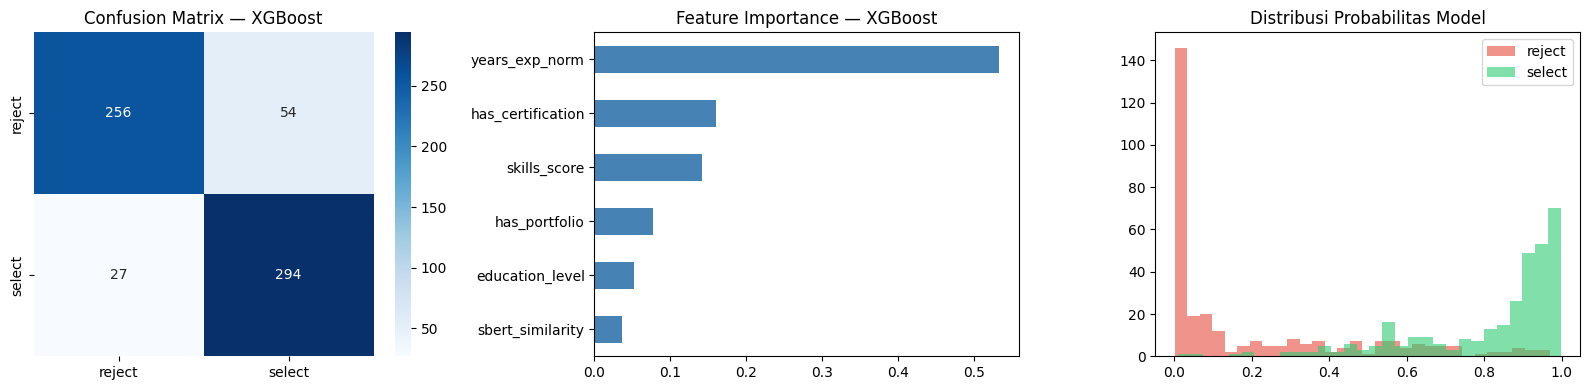

In [228]:
# Visualisasi
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Confusion matrix model terbaik
cm = confusion_matrix(y_test, best_model.predict(X_test))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['reject','select'],
            yticklabels=['reject','select'], ax=axes[0])
axes[0].set_title(f'Confusion Matrix — {best_name}')

# Feature importance
if hasattr(best_model, 'feature_importances_'):
    fi = pd.Series(best_model.feature_importances_, index=FEATURE_COLS).sort_values()
    fi.plot(kind='barh', ax=axes[1], color='steelblue')
    axes[1].set_title(f'Feature Importance — {best_name}')

# Score distribution
y_proba_best = best_model.predict_proba(X_test)[:,1]
for label, color in [(0,'#e74c3c'),(1,'#2ecc71')]:
    axes[2].hist(y_proba_best[y_test==label], bins=30,
                 alpha=0.6, label=['reject','select'][label], color=color)
axes[2].set_title('Distribusi Probabilitas Model')
axes[2].legend()

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

### SAVE MODEL

In [229]:
y_proba_best = best_model.predict_proba(X_test)[:, 1]
prec, rec, thrs = precision_recall_curve(y_test, y_proba_best)
f1s      = 2 * prec * rec / (prec + rec + 1e-8)
best_thr = float(thrs[np.argmax(f1s[:-1])])

THRESHOLD_LOLOS  = round(min(best_thr + 0.10, 0.90), 3)
THRESHOLD_REVIEW = round(max(best_thr - 0.10, 0.20), 3)

print(f'Threshold optimal (max F1) : {best_thr:.4f}')
print(f'Threshold LOLOS            : >= {THRESHOLD_LOLOS}')
print(f'Threshold PERLU_REVIEW     : >= {THRESHOLD_REVIEW}')
print(f'Threshold TIDAK_LOLOS      : <  {THRESHOLD_REVIEW}\n')

Threshold optimal (max F1) : 0.3951
Threshold LOLOS            : >= 0.495
Threshold PERLU_REVIEW     : >= 0.295
Threshold TIDAK_LOLOS      : <  0.295



In [230]:
# Simpan Model
model_path = f'{OUTPUT_DIR}/cv_screening_model.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(best_model, f)
print(f'Model tersimpan  : {model_path}')

Model tersimpan  : /content/drive/MyDrive/Kuliah/SEMESTER 6/AI/Tugas Besar/models/cv_screening_model.pkl


In [231]:
# Simpan JD Embeddings
jd_emb_path = f'{OUTPUT_DIR}/jd_embeddings.json'
with open(jd_emb_path, 'w') as f:
    json.dump({k: v.tolist() for k, v in jd_emb_dict.items()}, f)
print(f'JD embeddings    : {jd_emb_path}')

JD embeddings    : /content/drive/MyDrive/Kuliah/SEMESTER 6/AI/Tugas Besar/models/jd_embeddings.json


In [232]:
# Simpan config.json
config = {
    'model_name'       : best_name,
    'sbert_model'      : SBERT_MODEL_NAME,
    'feature_cols'     : FEATURE_COLS,
    'skills_per_role'  : SKILLS_PER_ROLE,
    'threshold_lolos'  : THRESHOLD_LOLOS,
    'threshold_review' : THRESHOLD_REVIEW,
    'roles'            : list(JD_REAL.keys()),
    'metrics': {
        'accuracy'  : round(results[best_name]['acc_test'], 4),
        'f1_score'  : round(results[best_name]['f1'], 4),
        'auc_roc'   : round(results[best_name]['auc_roc'], 4),
        'cv_f1_mean': round(results[best_name]['cv_f1_mean'], 4),
        'overfit_gap': round(results[best_name]['overfit_gap'], 4),
    }
}
config_path = f'{OUTPUT_DIR}/config.json'
with open(config_path, 'w') as f:
    json.dump(config, f, indent=2)
print(f'Config tersimpan : {config_path}')

Config tersimpan : /content/drive/MyDrive/Kuliah/SEMESTER 6/AI/Tugas Besar/models/config.json


In [233]:
print('OUTPUT SIAP DIGUNAKAN DI FastAPI:')
print(f'  {OUTPUT_DIR}/')
print(f'  ├── cv_screening_model.pkl')
print(f'  ├── jd_embeddings.json')
print(f'  └── config.json')
print(f'\nSalin 3 file ini ke folder models/ di project FastAPI-mu.')
print(f'\nConfig summary:')
print(json.dumps({
    'model': config['model_name'],
    'roles': config['roles'],
    'threshold_lolos': config['threshold_lolos'],
    'threshold_review': config['threshold_review'],
    'metrics': config['metrics']
}, indent=2))

OUTPUT SIAP DIGUNAKAN DI FastAPI:
  /content/drive/MyDrive/Kuliah/SEMESTER 6/AI/Tugas Besar/models/
  ├── cv_screening_model.pkl
  ├── jd_embeddings.json
  └── config.json

Salin 3 file ini ke folder models/ di project FastAPI-mu.

Config summary:
{
  "model": "XGBoost",
  "roles": [
    "Data Analyst",
    "Data Engineer",
    "Data Scientist",
    "Software Engineer",
    "Hr Specialist"
  ],
  "threshold_lolos": 0.495,
  "threshold_review": 0.295,
  "metrics": {
    "accuracy": 0.8716,
    "f1_score": 0.8789,
    "auc_roc": 0.9455,
    "cv_f1_mean": 0.868,
    "overfit_gap": 0.0018
  }
}


### TES INFERENCE LOKAL

In [234]:
def predict_cv_local(cv_text: str, role: str,
                     years_exp: int = None,
                     has_portfolio_form: bool = None) -> dict:
    """Fungsi inference lokal — sama persis dengan yang ada di FastAPI."""
    role = role.strip().title()
    if role not in jd_emb_dict:
        return {'error': f'Role tidak dikenali: {role}'}

    # Clean
    cv_clean = clean_text(cv_text)

    # SBERT
    cv_emb = sbert.encode(cv_clean, normalize_embeddings=True)
    jd_emb = jd_emb_dict[role]
    sim    = float(cosine_similarity(cv_emb.reshape(1,-1), jd_emb.reshape(1,-1))[0][0])

    # Fitur
    skills = extract_skills_score(cv_clean, role)
    exp    = (min(int(years_exp), 8) / 8.0) if years_exp is not None \
             else extract_years_experience(cv_clean)
    port   = int(has_portfolio_form) if has_portfolio_form is not None \
             else extract_has_portfolio(cv_clean)
    cert   = extract_has_certification(cv_clean)
    edu    = extract_education_level(cv_clean)

    # Predict
    X_inf  = np.array([[sim, skills, exp, port, cert, edu]], dtype=np.float32)
    proba  = float(best_model.predict_proba(X_inf)[0][1])
    score  = round(proba * 100, 1)

    keputusan = (
        'LOLOS'        if proba >= THRESHOLD_LOLOS  else
        'PERLU_REVIEW' if proba >= THRESHOLD_REVIEW else
        'TIDAK_LOLOS'
    )

    return {
        'role'       : role,
        'final_score': score,
        'probability': round(proba, 4),
        'keputusan'  : keputusan,
        'breakdown'  : {
            'sbert_similarity'  : round(sim,    3),
            'skills_score'      : round(skills, 3),
            'years_exp_norm'    : round(exp,    3),
            'has_portfolio'     : bool(port),
            'has_certification' : bool(cert),
            'education_level'   : round(edu,    3),
        }
    }


# Test 1 — Kandidat kuat
print('TEST 1: Kandidat kuat — Data Analyst')
r1 = predict_cv_local(
    cv_text='''
        Sarah Chen — Senior Data Analyst. 5 years experience.
        Skills: SQL advanced, Python, Pandas, Power BI, Tableau, BigQuery,
        data warehouse, dimensional modeling, A/B testing, statistics, dbt, ETL.
        Experience: Senior Data Analyst TechCorp (Jan 2021-Present),
        Data Analyst DataStartup (Mar 2019-Dec 2020).
        Education: Bachelor Statistics University Indonesia.
        Certifications: Google Data Analytics Certificate.
        Portfolio: github.com/sarahchen
    ''',
    role='Data Analyst', years_exp=5, has_portfolio_form=True
)
print(json.dumps(r1, indent=2))

# Test 2 — Kandidat lemah
print('\nTEST 2: Kandidat lemah — Data Analyst')
r2 = predict_cv_local(
    cv_text='Fresh graduate. Skills: Microsoft Word Excel basic. High school diploma.',
    role='Data Analyst', years_exp=0, has_portfolio_form=False
)
print(json.dumps(r2, indent=2))

TEST 1: Kandidat kuat — Data Analyst
{
  "role": "Data Analyst",
  "final_score": 98.3,
  "probability": 0.9835,
  "keputusan": "LOLOS",
  "breakdown": {
    "sbert_similarity": 0.625,
    "skills_score": 1.0,
    "years_exp_norm": 0.625,
    "has_portfolio": true,
    "has_certification": true,
    "education_level": 0.33
  }
}

TEST 2: Kandidat lemah — Data Analyst
{
  "role": "Data Analyst",
  "final_score": 0.2,
  "probability": 0.0016,
  "keputusan": "TIDAK_LOLOS",
  "breakdown": {
    "sbert_similarity": 0.493,
    "skills_score": 0.25,
    "years_exp_norm": 0.0,
    "has_portfolio": false,
    "has_certification": false,
    "education_level": 0.0
  }
}
